# Notebook 9 — GRPO & the DeepSeek-R1 Line of Work

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. **GRPO & the DeepSeek-R1 line of work** ← *you are here*
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

Still **only `numpy` and `matplotlib`**.

### Recap

Notebook 8 showed that for LLMs with verifiable rewards we can drop the
critic: sample a **group** of $K$ completions per prompt and use the other
samples as the baseline (RLOO). Notebook 6 gave us PPO's clipped objective for
taking several safe steps per batch, and the k3 KL estimator. **GRPO — Group
Relative Policy Optimization** (Shao et al., 2024, *DeepSeekMath*) is
essentially those two notebooks glued together, plus two extra design choices.
It's the algorithm behind **DeepSeek-R1**, and today the default for
reasoning RL.

Because it's so widely used, GRPO has also been dissected thoroughly. Two of
its design choices were later shown to introduce **biases** (*Dr. GRPO*, Liu
et al., 2025), and several practical fixes were proposed (*DAPO*, Yu et al.,
2025). We'll implement all of them and look at each one in isolation.

### What this notebook covers

- The GRPO objective, term by term, mapped back to notebooks 5, 6 and 8.
- A from-scratch GRPO implementation, gradient-checked, with switches for every
  design choice.
- **Std normalization** → a **difficulty bias**, derived and measured.
- **Per-response length normalization** ($1/|o_i|$) → a **length bias**, derived
  and measured.
- **The KL term** (k3, in the loss rather than in the reward), and why many
  recent recipes set $\beta = 0$.
- DAPO's fixes: **clip-higher**, **dynamic sampling**, **token-level loss**.
- The **DeepSeek-R1** pipeline (R1-Zero → R1 → distillation) and what can and
  can't be reproduced in a toy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ---------------- From notebooks 4-6, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]

    def clone(self):
        c = MLP.__new__(MLP)
        c.activation = self.activation
        c.params = [{k: v.copy() for k, v in p.items()} for p in self.params]
        return c


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)

def add_grads(g1, g2):
    return [{k: a[k] + b[k] for k in a} for a, b in zip(g1, g2)]

# ---- A tiny "math" world with a VERIFIABLE reward ----
VOCAB = [str(d) for d in range(10)] + ["=", "hmm", "<eos>"]
V, EQ, HMM, EOS = len(VOCAB), 10, 11, 12
N = 10                                             # operands 0..9 -> sums 0..18
L = 8                                              # max response length incl. <eos>
PROMPTS = [(a, b) for a in range(N) for b in range(N)]
N_PROMPTS = len(PROMPTS)
DIFFICULTY = np.array([0 if a + b < 6 else (1 if a + b < 12 else 2) for a, b in PROMPTS])   # easy / medium / hard
DIFF_NAMES = ["easy (sum<6)", "medium (6-11)", "hard (12-18)"]

def words_of(toks):
    out = []
    for t in toks:
        if t == EOS:
            break
        out.append(int(t))
    return out

def text(toks):
    return " ".join(VOCAB[t] for t in words_of(toks)) or "(empty)"

def well_formed(toks):
    """Format check: '= <1 or 2 digits>' at the end, anything (e.g. 'hmm') before the '='."""
    w = words_of(toks)
    if EQ not in w:
        return False
    ans = w[w.index(EQ) + 1:]
    return 1 <= len(ans) <= 2 and all(t < 10 for t in ans)

def verify(pid, toks):
    """The verifier: 1.0 iff the response is well formed AND the number after '=' is a+b."""
    if not well_formed(toks):
        return 0.0
    w = words_of(toks)
    ans = w[w.index(EQ) + 1:]
    return float(int("".join(VOCAB[t] for t in ans)) == sum(PROMPTS[pid]))

FEAT_DIM = N + N + L + V + (V + 1)

def lm_features(pids, prefix, t):
    B = len(pids)
    a = np.array([PROMPTS[i][0] for i in pids]); b = np.array([PROMPTS[i][1] for i in pids])
    bag = np.zeros((B, V))
    for j in range(prefix.shape[1]):
        bag[np.arange(B), prefix[:, j]] += 1
    last = np.zeros((B, V + 1))
    last[np.arange(B), prefix[:, -1] if prefix.shape[1] else V] = 1
    return np.concatenate([np.eye(N)[a], np.eye(N)[b], np.tile(np.eye(L)[t], (B, 1)), bag, last], axis=1)

POS_MASK = np.zeros((L, V)); POS_MASK[L - 1, :EOS] = -1e9      # the last position must be <eos>

def generate(policy, pids, rng):
    B = len(pids)
    toks = np.full((B, L), EOS); alive = np.ones(B, dtype=bool)
    feats, masks = [], []
    for t in range(L):
        f = lm_features(pids, toks[:, :t], t)
        p = softmax(policy.predict(f) + POS_MASK[t])
        a = (rng.random((B, 1)) > p.cumsum(axis=1)).sum(axis=1).clip(max=V - 1)
        a = np.where(alive, a, EOS)
        toks[:, t] = a; feats.append(f); masks.append(alive.copy())
        alive &= (a != EOS)
    return toks, np.stack(feats, 1), np.stack(masks, 1).astype(float)

def token_logprobs(policy, feats, toks):
    B, T, D = feats.shape
    logits = policy.predict(feats.reshape(B * T, D)).reshape(B, T, V) + POS_MASK[None]
    return np.take_along_axis(np.log(softmax(logits) + 1e-12), toks[..., None], axis=2)[..., 0]

def demonstration(pid, rng):
    """Noisy SFT data: right answer with a probability that falls with difficulty; 'hmm' filler; typos."""
    s = sum(PROMPTS[pid])
    q = [0.85, 0.4, 0.06][DIFFICULTY[pid]]
    ans = s if rng.random() < q else max(0, s + int(rng.choice([-2, -1, 1, 2])))
    digits = [int(c) for c in str(ans)]
    if rng.random() < 0.1:
        digits = digits + [int(rng.integers(10))]            # a typo: a stray extra digit
    return [HMM] * int(rng.choice([0, 0, 1, 2, 3])) + [EQ] + digits + [EOS]

def sft_base_model(n_steps=2500, batch=256, lr=2e-3, seed=0):
    rng = np.random.default_rng(seed)
    policy = MLP([FEAT_DIM, 128, 128, V], "tanh", seed=seed)
    opt = Adam(policy.params, lr=lr)
    for _ in range(n_steps):
        pids = rng.integers(N_PROMPTS, size=batch)
        toks = np.full((batch, L), EOS); mask = np.zeros((batch, L))
        for i, p in enumerate(pids):
            seq = demonstration(p, rng)[:L]
            toks[i, :len(seq)] = seq; mask[i, :len(seq)] = 1
        feats = np.stack([lm_features(pids, toks[:, :t], t) for t in range(L)], axis=1)
        logits, cache = policy.forward(feats.reshape(batch * L, FEAT_DIM))
        p = softmax(logits + np.tile(POS_MASK, (batch, 1)))
        m = mask.reshape(-1, 1)
        opt.step(policy.backward(cache, (p - np.eye(V)[toks.reshape(-1)]) * m / m.sum()))
    return policy

def per_prompt_accuracy(policy, n_samples=64, seed=0):
    """Monte-Carlo estimate of p(correct | prompt) for all 100 prompts."""
    rng = np.random.default_rng(seed)
    pids = np.repeat(np.arange(N_PROMPTS), n_samples)
    toks, _, _ = generate(policy, pids, rng)
    return np.array([verify(p, t) for p, t in zip(pids, toks)]).reshape(N_PROMPTS, n_samples).mean(axis=1)

def pass_at_k(p, k):
    """Expected pass@k averaged over prompts, given per-prompt single-sample success rates p."""
    return np.mean(1 - (1 - p) ** k)


t0 = time.time()
base_model = sft_base_model()
acc_base = per_prompt_accuracy(base_model, n_samples=128)
print(f"base model (same SFT recipe as notebook 8) trained in {time.time() - t0:.0f}s; pass@1 = {acc_base.mean():.3f}")
for d, name in enumerate(DIFF_NAMES):
    print(f"   {name:>14}: {acc_base[DIFFICULTY == d].mean():.3f}")

base model (same SFT recipe as notebook 8) trained in 22s; pass@1 = 0.371
     easy (sum<6): 0.735
    medium (6-11): 0.386
     hard (12-18): 0.071


## 1. The GRPO objective, one piece at a time

For a prompt $q$, sample a group of $G$ outputs $o_1,\dots,o_G$ from the old policy
$\pi_{\theta_{\text{old}}}$ and score them: rewards $r_1,\dots,r_G$. GRPO maximizes

$$
\mathcal J_{\text{GRPO}}(\theta) = \frac{1}{G}\sum_{i=1}^{G}\;\underbrace{\frac{1}{|o_i|}\sum_{t=1}^{|o_i|}}_{\text{(4)}}\Big[\;\underbrace{\min\big(\rho_{i,t}\hat A_{i},\ \mathrm{clip}(\rho_{i,t}, 1-\epsilon, 1+\epsilon)\,\hat A_{i}\big)}_{\text{(2) PPO-clip, notebook 6}} \;-\; \underbrace{\beta\, \mathbb D_{\text{KL}}^{(t)}\big[\pi_\theta\,\|\,\pi_{\text{ref}}\big]}_{\text{(3) k3 estimator, notebook 6}}\Big],
$$

with

$$
\rho_{i,t} = \frac{\pi_\theta(o_{i,t}\mid q, o_{i,<t})}{\pi_{\theta_{\text{old}}}(o_{i,t}\mid q, o_{i,<t})},
\qquad
\underbrace{\hat A_i = \frac{r_i - \text{mean}(r_{1..G})}{\text{std}(r_{1..G})}}_{\text{(1) group baseline, notebook 8 — plus a division by std}},
\qquad
\mathbb D_{\text{KL}}^{(t)} = \frac{\pi_{\text{ref}}}{\pi_\theta} - \log\frac{\pi_{\text{ref}}}{\pi_\theta} - 1 .
$$

Piece by piece:

1. **Group-relative advantage.** Like RLOO, the baseline is the group's mean
   reward — but *including* $r_i$ itself (a small bias; notebook 8, Section 3),
   and **divided by the group's standard deviation**. Every token of $o_i$
   shares $\hat A_i$ (the bandit view).
2. **PPO-clip** per token, so we can take several gradient steps
   ($\mu$ "iterations") per batch of generations.
3. **KL to the reference model**, estimated per token with k3 (unbiased,
   always ≥ 0), and added to the **loss**, not folded into the reward as in
   notebook 7. That keeps the advantage purely about the task reward.
4. **Length normalization**: each response's token losses are *averaged*
   ($1/|o_i|$) before averaging over the group.

Items (1)'s std and (4) look innocent. Sections 4 and 5 show they aren't.

### The gradient, for one token

With $w_{i,t}$ the aggregation weight of token $(i,t)$ (e.g. $\frac{1}{G|o_i|}$) and
$r = \pi_{\text{ref}}/\pi_\theta$, the loss is $-\mathcal J$, so per token:

$$
\frac{\partial(-\mathcal J)}{\partial\,\text{logits}} = -\,w_{i,t}\Big[\underbrace{\hat A_i\,\rho_{i,t}\,\mathbb 1[\text{not clipped}]}_{\text{notebook 6}} \;-\; \beta\,(1 - r)\Big]\big(\text{onehot}(o_{i,t}) - \pi_\theta\big),
$$

using $\partial\,\text{k3}/\partial\log\pi_\theta = 1 - r$. We verify it numerically before
building on it.

In [2]:
def grpo_token_loss(logits, acts, A, old_lp, ref_lp, w, beta, eps_low, eps_high):
    p = softmax(logits); lp = np.log(p[np.arange(len(acts)), acts] + 1e-12)
    rho = np.exp(lp - old_lp)
    surr = np.minimum(rho * A, np.clip(rho, 1 - eps_low, 1 + eps_high) * A)
    k3 = np.exp(ref_lp - lp) - (ref_lp - lp) - 1
    return -np.sum(w * (surr - beta * k3))

def grpo_token_grad(logits, acts, A, old_lp, ref_lp, w, beta, eps_low, eps_high):
    p = softmax(logits); lp = np.log(p[np.arange(len(acts)), acts] + 1e-12)
    rho = np.exp(lp - old_lp)
    clipped = ((A > 0) & (rho > 1 + eps_high)) | ((A < 0) & (rho < 1 - eps_low))
    coef = w * (np.where(clipped, 0.0, A * rho) - beta * (1 - np.exp(ref_lp - lp)))
    return -(coef[:, None] * (np.eye(p.shape[1])[acts] - p)), clipped

rng = np.random.default_rng(0)
n = 20
logits = rng.normal(size=(n, V)); acts = rng.integers(V, size=n); A = rng.normal(size=n)
cur_lp = np.log(softmax(logits)[np.arange(n), acts])
old_lp = cur_lp + rng.normal(0, 0.3, size=n); ref_lp = cur_lp + rng.normal(0, 0.5, size=n)
w = rng.random(n); args = (acts, A, old_lp, ref_lp, w, 0.1, 0.2, 0.28)
analytic, clipped = grpo_token_grad(logits, *args)
numeric = np.zeros_like(logits)
for i in range(n):
    for j in range(V):
        e = np.zeros_like(logits); e[i, j] = 1e-6
        numeric[i, j] = (grpo_token_loss(logits + e, *args) - grpo_token_loss(logits - e, *args)) / 2e-6
print(f"{clipped.sum()} of {n} tokens clipped;  max |analytic - numeric| = {np.abs(analytic - numeric).max():.2e}")
assert np.allclose(analytic, numeric, atol=1e-6)

3 of 20 tokens clipped;  max |analytic - numeric| = 6.35e-10


## 2. GRPO from scratch, with a switch for every design choice

One function, with the options the literature argues about:

| option | GRPO (DeepSeekMath) | Dr. GRPO | DAPO |
|---|---|---|---|
| `scale_rewards` — divide advantages by group std | yes | **no** | yes |
| `loss_type` — how token losses are aggregated | `"grpo"`: mean over each response's tokens, then over responses | `"dr_grpo"`: sum over tokens ÷ (G × max_len), a constant | `"dapo"`: mean over **all tokens in the batch** |
| `eps_low / eps_high` — clip range | 0.2 / 0.2 | 0.2 / 0.2 | 0.2 / **0.28** ("clip-higher") |
| `beta` — KL to reference | 0.04 | 0 | 0 |
| `dynamic_sampling` — resample zero-variance groups | no | no | **yes** |

(`trl.GRPOConfig` exposes exactly these knobs under the same names — notebook 10.)

GRPO: 200 iterations in 4s


pass@1: base 0.371 -> GRPO 0.951
     easy (sum<6): 0.735 -> 0.986
    medium (6-11): 0.386 -> 0.946
     hard (12-18): 0.071 -> 0.934


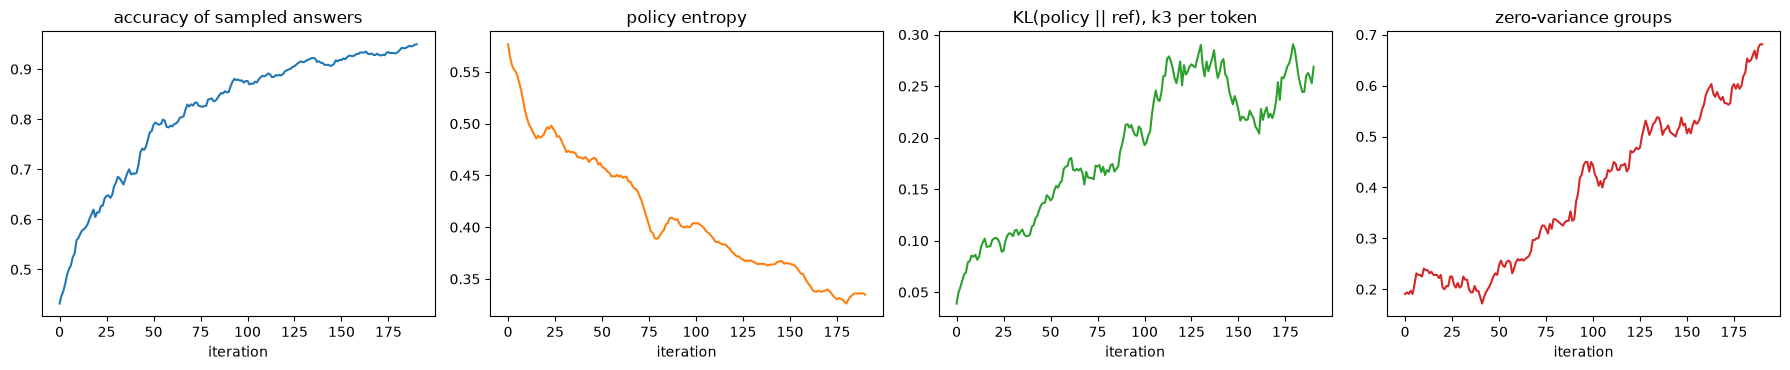

In [3]:
def grpo_train(reference, n_iters=200, P=32, G=8, lr=1e-3, mu=2, scale_rewards=True, loss_type="grpo",
               eps_low=0.2, eps_high=0.2, beta=0.0, dynamic_sampling=False, reward_fn=verify, seed=0):
    rng = np.random.default_rng(seed)
    policy = reference.clone(); opt = Adam(policy.params, lr=lr)
    log = {k: [] for k in ["accuracy", "entropy", "kl", "len_correct", "len_wrong",
                           "zero_var_frac", "samples_generated", "clip_frac"]}
    total_samples = 0
    for it in range(n_iters):
        # ---- 1. generate groups (with DAPO dynamic sampling: keep only groups with reward variance) ----
        kept_toks, kept_feats, kept_mask, kept_pids, kept_R, zero_var = [], [], [], [], [], []
        tries = 0
        while True:
            pids = np.repeat(rng.integers(N_PROMPTS, size=P), G)
            toks, feats, mask = generate(policy, pids, rng); total_samples += len(pids)
            R = np.array([reward_fn(p, t) for p, t in zip(pids, toks)]).reshape(P, G)
            informative = R.std(axis=1) > 0
            zero_var.append(1 - informative.mean())
            sel = np.repeat(informative, G) if dynamic_sampling else np.ones(P * G, bool)
            kept_toks.append(toks[sel]); kept_feats.append(feats[sel]); kept_mask.append(mask[sel])
            kept_pids.append(pids[sel]); kept_R.append(R[informative] if dynamic_sampling else R)
            tries += 1
            n_groups = sum(len(r) for r in kept_R)
            if not dynamic_sampling or n_groups >= P or tries >= 8:
                break
        toks, feats, mask = np.concatenate(kept_toks), np.concatenate(kept_feats), np.concatenate(kept_mask)
        pids, R = np.concatenate(kept_pids), np.concatenate(kept_R)
        if len(R) == 0:
            continue
        # ---- 2. group-relative advantages ----
        A = R - R.mean(axis=1, keepdims=True)
        if scale_rewards:
            A = A / (R.std(axis=1, keepdims=True) + 1e-4)
        A = A.reshape(-1)
        # ---- 3. token aggregation weights ----
        n_seq = len(A); lengths = mask.sum(axis=1)
        if loss_type == "grpo":
            w = mask / lengths[:, None] / n_seq
        elif loss_type == "dr_grpo":
            w = mask / (n_seq * L)
        elif loss_type == "dapo":
            w = mask / mask.sum()
        # ---- 4. flatten real tokens; old and reference log-probs ----
        B, T, D = feats.shape
        keep = mask.reshape(-1).astype(bool)
        F = feats.reshape(B * T, D)[keep]; acts = toks.reshape(-1)[keep]
        Atok = np.repeat(A, T)[keep]; W = w.reshape(-1)[keep]; PM = np.tile(POS_MASK, (B, 1))[keep]
        old_lp = token_logprobs(policy, feats, toks).reshape(-1)[keep]
        ref_lp = token_logprobs(reference, feats, toks).reshape(-1)[keep]
        # ---- 5. mu gradient steps on the same generations ----
        for _ in range(mu):
            logits, cache = policy.forward(F)
            d, clipped = grpo_token_grad(logits + PM, acts, Atok, old_lp, ref_lp, W, beta, eps_low, eps_high)
            opt.step(policy.backward(cache, d), max_norm=1.0)
        p = softmax(logits + PM); lp = np.log(p[np.arange(len(acts)), acts] + 1e-12)
        correct = np.array([verify(pp, t) for pp, t in zip(pids, toks)])
        log["accuracy"].append(correct.mean())
        log["entropy"].append(-(p * np.log(p + 1e-12)).sum(axis=1).mean())
        log["kl"].append(np.mean(np.exp(ref_lp - lp) - (ref_lp - lp) - 1))
        log["len_correct"].append(lengths[correct == 1].mean() if correct.any() else np.nan)
        log["len_wrong"].append(lengths[correct == 0].mean() if (correct == 0).any() else np.nan)
        log["zero_var_frac"].append(zero_var[0])
        log["samples_generated"].append(total_samples)
        log["clip_frac"].append(clipped.mean())
    return policy, {k: np.array(v) for k, v in log.items()}

def smooth(x, k=10):
    x = np.asarray(x, dtype=float)
    return np.convolve(np.nan_to_num(x, nan=np.nanmean(x)), np.ones(k) / k, mode="valid")

t0 = time.time()
grpo_policy, grpo_log = grpo_train(base_model, scale_rewards=True, loss_type="grpo", beta=0.04)
print(f"GRPO: 200 iterations in {time.time() - t0:.0f}s")
acc_grpo = per_prompt_accuracy(grpo_policy, n_samples=128, seed=4)
print(f"pass@1: base {acc_base.mean():.3f} -> GRPO {acc_grpo.mean():.3f}")
for d, name in enumerate(DIFF_NAMES):
    print(f"   {name:>14}: {acc_base[DIFFICULTY == d].mean():.3f} -> {acc_grpo[DIFFICULTY == d].mean():.3f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
axes[0].plot(smooth(grpo_log["accuracy"])); axes[0].set_title("accuracy of sampled answers")
axes[1].plot(smooth(grpo_log["entropy"]), color="C1"); axes[1].set_title("policy entropy")
axes[2].plot(smooth(grpo_log["kl"]), color="C2"); axes[2].set_title("KL(policy || ref), k3 per token")
axes[3].plot(smooth(grpo_log["zero_var_frac"]), color="C3"); axes[3].set_title("zero-variance groups")
for ax in axes: ax.set_xlabel("iteration")
plt.tight_layout(); plt.show()

Standard GRPO takes the base model from roughly a third correct to nearly
always correct, including most hard prompts, while the k3 KL term keeps it
anchored to the reference. As it improves, more groups become all-correct and
stop contributing (notebook 8, Section 4).

Now let's take the design choices apart.

## 3. Std normalization creates a difficulty bias

With 0/1 rewards and a group success rate $p$, the group std is $\sqrt{p(1-p)}$.
A correct sample gets $\hat A = (1-p)/\sqrt{p(1-p)} = \sqrt{(1-p)/p}$ and a wrong one
$-\sqrt{p/(1-p)}$. The average magnitude of the advantages in a group is:

$$
\mathbb E|\hat A| = \underbrace{2p(1-p)}_{\text{without std (RLOO / Dr. GRPO, up to a constant)}}
\qquad\text{vs.}\qquad
\underbrace{2\sqrt{p(1-p)}}_{\text{with std (GRPO)}} .
$$

Dividing by the std **multiplies each prompt's gradient by $1/\sqrt{p(1-p)}$**,
which blows up as $p \to 0$ or $p \to 1$. So GRPO gives *relatively more weight*
to prompts that are **almost always solved** or **almost never solved**, and
less to the intermediate ones. That's not an unbiased estimate of the gradient
of expected reward; it's a reweighting of prompts by difficulty. Dr. GRPO argues
it's unwanted. Others argue that upweighting rare successes on hard prompts is
a feature. Either way it's a *choice*, and you should know you're making it.

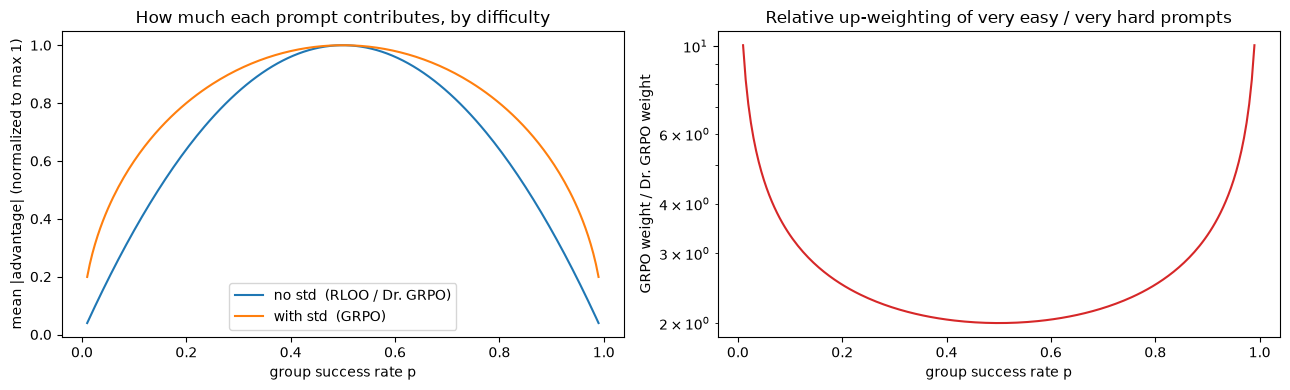

In [4]:
p = np.linspace(0.01, 0.99, 197)
no_std = 2 * p * (1 - p); with_std = 2 * np.sqrt(p * (1 - p))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(p, no_std / no_std.max(), label="no std  (RLOO / Dr. GRPO)")
axes[0].plot(p, with_std / with_std.max(), label="with std  (GRPO)")
axes[0].set_xlabel("group success rate p"); axes[0].set_ylabel("mean |advantage| (normalized to max 1)")
axes[0].set_title("How much each prompt contributes, by difficulty"); axes[0].legend()
axes[1].plot(p, with_std / no_std, color="C3")
axes[1].set_yscale("log"); axes[1].set_xlabel("group success rate p")
axes[1].set_ylabel("GRPO weight / Dr. GRPO weight"); axes[1].set_title("Relative up-weighting of very easy / very hard prompts")
plt.tight_layout(); plt.show()

## 4. Per-response length normalization creates a length bias

Look at the aggregation weight in GRPO's loss: token $t$ of response $i$ gets
$w_{i,t} = \frac{1}{G\,|o_i|}$. Every token's push is **divided by its own
response's length**. So:

- A **correct** response ($\hat A > 0$) that is *short* gets a bigger per-token
  push up than a long correct one → a mild preference for **short correct**
  answers.
- A **wrong** response ($\hat A < 0$) that is *long* gets a *smaller* per-token
  push down than a short wrong one → **long wrong answers are penalized less**.

The second effect is the one Dr. GRPO highlighted. Over long training it lets
incorrect responses grow longer and longer, which can masquerade as "the model
learned to think longer." The fix is to use a normalizer that doesn't depend on
the individual response — Dr. GRPO divides by a constant (G × max length); DAPO
averages over all tokens in the batch.

We can see the effect precisely, without any training, by computing the per-token
"push-down" weight each wrong response receives in one batch from the base
model:

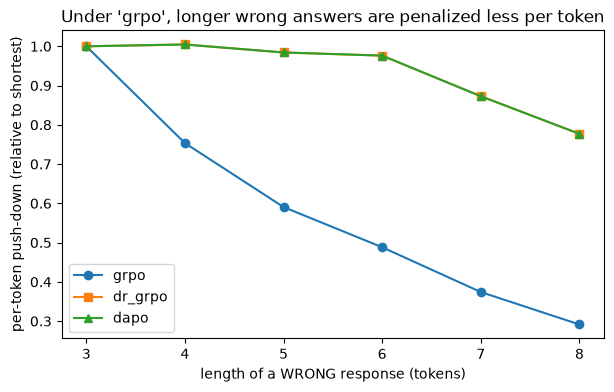

In [5]:
rng = np.random.default_rng(0)
pids = np.repeat(rng.integers(N_PROMPTS, size=64), 8)
toks, feats, mask = generate(base_model, pids, rng)
R = np.array([verify(p, t) for p, t in zip(pids, toks)]).reshape(64, 8)
A = ((R - R.mean(1, keepdims=True)) / (R.std(1, keepdims=True) + 1e-4)).reshape(-1)
lengths = mask.sum(axis=1)
wrong = (A < 0)
fig, ax = plt.subplots(figsize=(7, 4))
for loss_type, marker in [("grpo", "o"), ("dr_grpo", "s"), ("dapo", "^")]:
    if loss_type == "grpo":   w_seq = 1 / lengths / len(A)
    elif loss_type == "dr_grpo": w_seq = np.full(len(A), 1 / (len(A) * L))
    else:                     w_seq = np.full(len(A), 1 / mask.sum())
    per_token = np.abs(A * w_seq)
    xs = sorted(set(lengths[wrong]))
    ys = [per_token[wrong & (lengths == x)].mean() for x in xs]
    ax.plot(xs, np.array(ys) / ys[0], marker + "-", label=loss_type)
ax.set_xlabel("length of a WRONG response (tokens)"); ax.set_ylabel("per-token push-down (relative to shortest)")
ax.set_title("Under 'grpo', longer wrong answers are penalized less per token"); ax.legend(); plt.show()

With `"grpo"` aggregation, a wrong answer twice as long gets roughly half the
per-token penalty — the steep $1/|o_i|$ curve. With `"dr_grpo"` or `"dapo"`, the
aggregation weight is the same for every token. Those curves still drift down
a little, but only because long wrong answers tend to come from groups with a
different success rate (so their advantages differ). There's no built-in
$1/\text{length}$ discount.

Whether this bias shows up as visibly longer responses depends on training
length and on how much the task *allows* length to vary. Our toy gives the
model only 0–3 filler tokens and 200 updates, so the lengths of wrong answers
barely diverge. In DeepSeek-scale runs with thousand-token responses and
thousands of updates, the effect is large enough to matter. Let's compare the
three variants on the same budget:

9 runs in 191s



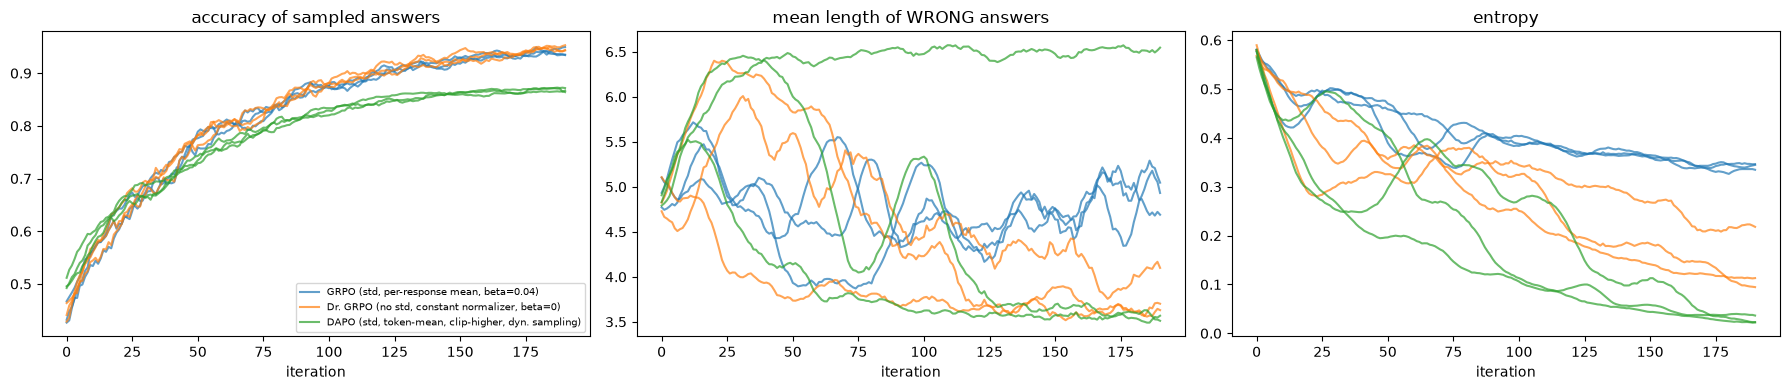

                                             variant | pass@1 | hard prompts | samples generated


            GRPO (std, per-response mean, beta=0.04) |  0.947 |        0.927 |            51,200


      Dr. GRPO (no std, constant normalizer, beta=0) |  0.951 |        0.940 |            51,200


  DAPO (std, token-mean, clip-higher, dyn. sampling) |  0.990 |        0.987 |           203,691


In [6]:
variants = {
    "GRPO (std, per-response mean, beta=0.04)": dict(scale_rewards=True, loss_type="grpo", beta=0.04),
    "Dr. GRPO (no std, constant normalizer, beta=0)": dict(scale_rewards=False, loss_type="dr_grpo", beta=0.0),
    "DAPO (std, token-mean, clip-higher, dyn. sampling)": dict(scale_rewards=True, loss_type="dapo", beta=0.0, eps_high=0.28, dynamic_sampling=True),
}
t0 = time.time()
runs = {name: [grpo_train(base_model, seed=s, **cfg) for s in range(3)] for name, cfg in variants.items()}
print(f"{3 * len(variants)} runs in {time.time() - t0:.0f}s\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for (name, rs), c in zip(runs.items(), ["C0", "C1", "C2"]):
    for s, (_, lg) in enumerate(rs):
        lab = name if s == 0 else None
        axes[0].plot(smooth(lg["accuracy"]), color=c, alpha=0.7, label=lab)
        axes[1].plot(smooth(lg["len_wrong"]), color=c, alpha=0.7, label=lab)
        axes[2].plot(smooth(lg["entropy"]), color=c, alpha=0.7, label=lab)
axes[0].set_title("accuracy of sampled answers"); axes[1].set_title("mean length of WRONG answers"); axes[2].set_title("entropy")
for ax in axes: ax.set_xlabel("iteration")
axes[0].legend(fontsize=7); plt.tight_layout(); plt.show()

print(f"{'variant':>52} | {'pass@1':>6} | {'hard prompts':>12} | {'samples generated':>17}")
for name, rs in runs.items():
    accs = np.array([per_prompt_accuracy(pol, seed=5) for pol, _ in rs]).mean(axis=0)
    gen = np.mean([lg["samples_generated"][-1] for _, lg in rs])
    print(f"{name:>52} | {accs.mean():6.3f} | {accs[DIFFICULTY == 2].mean():12.3f} | {gen:17,.0f}")

Read the plots together with the table, because one of them is misleading
at first glance:

- **DAPO's training-accuracy curve is *lower*, but its final pass@1 is the
  *highest*.** That's not a contradiction. With dynamic sampling, the logged
  accuracy is measured only on the groups DAPO *kept* — the ones with mixed
  results, which are harder than average. Always evaluate on a fixed, unfiltered
  set.
- **Dynamic sampling costs generation.** Every gradient step uses only
  informative groups, but DAPO generated about 4× as many samples to get
  them, and the gap grows as the model improves and more groups become
  all-correct. It bought the best final accuracy, especially on hard prompts,
  with extra compute.
- **Entropy: the KL term matters more than clip-higher here.** GRPO with
  $\beta = 0.04$ keeps the most entropy, because the reference model anchors it.
  DAPO's entropy collapses the *most*: clip-higher ($\epsilon_{\text{high}} = 0.28$)
  is meant to counter collapse, but in this configuration it's outweighed by
  $\beta = 0$ and by dynamic sampling, which makes every update count. Entropy
  collapse is one of the main practical problems of long GRPO runs; exercise 4
  isolates clip-higher's effect.
- **Length of wrong answers**: noisy and inconclusive across seeds. The
  length bias from Section 4 is real in the gradient, but it's a slow,
  long-horizon effect that 200 updates on 0–3 filler tokens can't reliably
  show. Honest calibration: these design choices are **second-order effects**
  over long runs on hard problems, not things that make or break a toy.

## 5. The KL term: estimator, placement, and whether to keep it

GRPO puts the k3 estimate of $\mathrm{KL}(\pi_\theta\|\pi_{\text{ref}})$ directly in the loss,
per token. Three things to know:

- **Why k3?** It's unbiased and always ≥ 0 (notebook 6, Section 4), so the
  per-token penalty never has the wrong sign.
- **Loss vs. reward.** Notebook 7 subtracted $\beta\log(\pi/\pi_{\text{ref}})$ from the reward,
  so the KL entered the advantages and the critic. GRPO keeps the advantage
  purely "how good was this answer," and regularizes separately.
- **Keep it at all?** With a *verifiable* reward there's no reward model to
  hack, so the main reason for the KL (notebook 7's Goodhart curve) is
  weaker. DAPO, Dr. GRPO and many recent recipes use $\beta = 0$, which also
  saves the memory of the reference model. The KL's remaining job is
  stability and preserving general abilities.

beta sweep in 433s


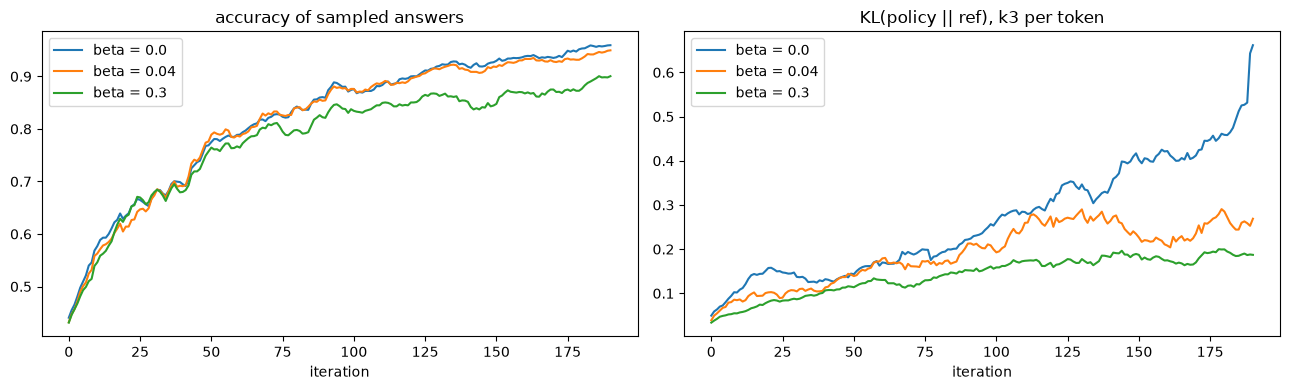

In [7]:
t0 = time.time()
kl_runs = {beta: grpo_train(base_model, beta=beta, seed=0)[1] for beta in [0.0, 0.04, 0.3]}
print(f"beta sweep in {time.time() - t0:.0f}s")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for beta, lg in kl_runs.items():
    axes[0].plot(smooth(lg["accuracy"]), label=f"beta = {beta}")
    axes[1].plot(smooth(lg["kl"]), label=f"beta = {beta}")
axes[0].set_title("accuracy of sampled answers"); axes[1].set_title("KL(policy || ref), k3 per token")
for ax in axes: ax.set_xlabel("iteration"); ax.legend()
plt.tight_layout(); plt.show()

A larger $\beta$ holds the policy closer to the reference (lower KL) at some cost
in how fast accuracy rises. With a trustworthy verifier, $\beta$ around 0–0.04
costs essentially nothing here.

## 6. The DeepSeek-R1 line of work

GRPO became famous through **DeepSeek-R1** (DeepSeek-AI, 2025). The pipeline,
and where each notebook of this course appears in it:

1. **R1-Zero — pure RL from a base model.** GRPO directly on a pretrained base
   (no SFT), with **rule-based rewards only**: an *accuracy reward* (a verifier,
   notebook 8) and a *format reward* (reasoning inside `<think>...</think>`).
   No learned reward model, precisely to avoid reward hacking (notebook 7).
   Reported result: long chains of thought *emerged* during RL, with response
   length growing steadily and self-verification behaviors ("wait, let me
   re-check…" — the "aha moment") appearing on their own. It also produced
   poor readability and language mixing.
2. **R1 — the practical recipe.**
   - **Cold-start SFT** on a few thousand curated long-CoT examples (notebook
     7's stage 1: RL only improves what the model already sometimes does).
   - **Reasoning-oriented GRPO** with accuracy + format + language-consistency
     rewards.
   - **Rejection-sampling SFT**: sample many responses from the RL model, keep
     the ones the verifier (or a judge) accepts, and SFT on them together with
     general data. (Notebook 5: that's REINFORCE with 0/1 advantages.)
   - **A second RL stage** for all scenarios, adding **reward models** for
     helpfulness and harmlessness (notebook 7) on top of the rule-based
     rewards.
3. **Distillation.** SFT smaller models on ~800k samples from R1. For small
   models, distilling from a strong teacher beat running RL on them directly.

**What a toy can and can't reproduce.** Everything algorithmic here is exact:
group advantages, clipping, the k3 KL, dynamic sampling, verifier hacking,
pass@k sharpening. What we *can't* reproduce is emergent long reasoning. That
needs a model with enough capacity that "spend more tokens thinking" genuinely
raises the probability of a correct answer. In our tiny model, `hmm` tokens
carry no computation. Keep that boundary in mind when reading claims about
what RL "teaches."

Related variants you'll meet: **GSPO** (sequence-level importance ratios
instead of per-token — `importance_sampling_level="sequence"` in `trl`),
**Dr. GRPO** and **DAPO** (above), and **REINFORCE++ / RLOO** (notebook 8).

## 7. The LLM mapping: `trl.GRPOConfig`

| our `grpo_train` argument | `trl.GRPOConfig` | meaning |
|---|---|---|
| `G` | `num_generations` | group size |
| `scale_rewards=True/False` | `scale_rewards` | divide by group std (GRPO) or not (Dr. GRPO) |
| `loss_type` | `loss_type` = `"grpo"`, `"dr_grpo"`, `"dapo"`, … | token aggregation |
| `eps_low`, `eps_high` | `epsilon`, `epsilon_high` | clip range (clip-higher) |
| `beta` | `beta` | k3 KL coefficient (0 disables the reference model) |
| `mu` | `num_iterations` | gradient steps per generation batch |
| `reward_fn=verify` | `reward_funcs=[...]` | Python functions and/or reward models |
| `zero_var_frac` | logged as `frac_reward_zero_std` | uninformative groups |

Notebook 10 runs `GRPOTrainer` on a real small LLM with a verifiable arithmetic
reward — the same experiment as this notebook, at the scale of a 135M-parameter
transformer.

## 8. Recap & exercises

**What we built:**

- The **GRPO objective** as group baseline (notebook 8) + PPO-clip (notebook 6)
  + k3 KL in the loss (notebook 6) + per-response length normalization — with
  a finite-difference-checked gradient.
- The **difficulty bias** of std normalization: GRPO weights prompts by
  $1/\sqrt{p(1-p)}$ relative to an unbiased estimator.
- The **length bias** of $1/|o_i|$ normalization: long wrong answers are
  penalized less per token, and the Dr. GRPO / DAPO fixes.
- DAPO's **clip-higher**, **dynamic sampling** and **token-level loss**, and the
  $\beta = 0$ trend for verifiable rewards.
- The **DeepSeek-R1** pipeline, mapped onto the course.

### Exercises

1. **Leave-one-out inside GRPO.** Replace the group mean with the leave-one-out
   mean (notebook 8). Measure the bias of both estimators against a large-sample
   "true" gradient, as in notebook 5's `grad_variance`.
2. **Make length matter.** Let responses contain up to 6 `hmm` tokens (raise `L`)
   and train 1,000 iterations with `loss_type="grpo"` vs. `"dr_grpo"`. Does the
   length of *wrong* answers drift apart?
3. **Sequence-level ratios (GSPO).** Replace per-token ratios with the
   geometric-mean sequence ratio $\big(\pi_\theta(o)/\pi_{\text{old}}(o)\big)^{1/|o|}$, shared by every
   token of the response. How does the clip fraction change?
4. **Entropy collapse.** Train 600 iterations with $\epsilon_{\text{high}} \in \{0.2, 0.28, 0.4\}$ and
   plot entropy and pass@16. Is there a trade-off between pass@1 and pass@k?
5. **R1-Zero in miniature.** Train GRPO from a *less* trained base model (e.g.
   `sft_base_model(n_steps=300)`), rewarding only `verify`. Then add a format
   reward. Which learns faster, and why?